In [4]:
import numpy as np
from pymoo.core.problem import ElementwiseProblem

class SchedulingProblem(ElementwiseProblem):
    def __init__(self, num_tasks=5, num_slots=3):
        self.num_tasks = num_tasks
        self.num_slots = num_slots
        super().__init__(n_var=num_tasks,
                         n_obj=2,
                         n_constr=0,
                         xl=0,
                         xu=num_slots - 1,
                         type_var=int)

    def _evaluate(self, x, out, *args, **kwargs):
        # x: array of task assignments to slots
        # For simplicity, assume each task has a duration and cost
        durations = np.array([2, 4, 3, 5, 1])  # example durations
        costs = np.array([10, 20, 15, 25, 5])  # example costs

        # Calculate total completion time per slot
        slot_times = np.zeros(self.num_slots)
        slot_costs = np.zeros(self.num_slots)
        for i in range(self.num_tasks):
            slot = int(round(x[i]))
            slot_times[slot] += durations[i]
            slot_costs[slot] += costs[i]

        # Objectives:
        # 1. Total completion time (makespan)
        # 2. Total cost
        out["F"] = [np.max(slot_times), np.sum(slot_costs)]

In [5]:
from pymoo.algorithms.moo.moead import MOEAD
from pymoo.util.ref_dirs import get_reference_directions

# Generate reference directions for 2 objectives
ref_dirs = get_reference_directions("uniform", 2, n_partitions=12)

algorithm = MOEAD(
    ref_dirs=ref_dirs,
    n_neighbors=15,
    prob_neighbor_mating=0.7
)

In [14]:
from pymoo.optimize import minimize

problem = SchedulingProblem()

res = minimize(problem,
               algorithm,
               ('n_gen', 100),
               seed=1,
               verbose=True)

n_gen  |  n_eval  | n_nds  |      eps      |   indicator  
     1 |       13 |      2 |             - |             -
     2 |       26 |     12 |  0.000000E+00 |             f
     3 |       39 |     12 |  0.000000E+00 |             f
     4 |       52 |     12 |  0.000000E+00 |             f
     5 |       65 |     12 |  0.000000E+00 |             f
     6 |       78 |     12 |  0.000000E+00 |             f
     7 |       91 |     12 |  0.000000E+00 |             f
     8 |      104 |     12 |  0.000000E+00 |             f
     9 |      117 |     12 |  0.000000E+00 |             f
    10 |      130 |     12 |  0.000000E+00 |             f
    11 |      143 |     12 |  0.000000E+00 |             f
    12 |      156 |     12 |  0.000000E+00 |             f
    13 |      169 |     12 |  0.000000E+00 |             f
    14 |      182 |     12 |  0.000000E+00 |             f
    15 |      195 |     12 |  0.000000E+00 |             f
    16 |      208 |     12 |  0.000000E+00 |            

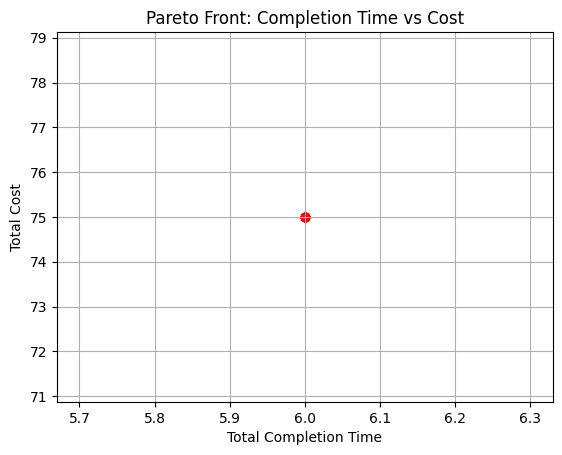

In [15]:
import matplotlib.pyplot as plt

F = res.F
plt.scatter(F[:, 0], F[:, 1], c='red')
plt.title("Pareto Front: Completion Time vs Cost")
plt.xlabel("Total Completion Time")
plt.ylabel("Total Cost")
plt.grid(True)
plt.show()